In [1]:
pip install tensorflow numpy matplotlib

In [2]:
"""
Dog vs Cat Image Classifier
Author: [Janaina]
Description: Build a simple neural network to classify dog and cat images
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Keras version: 3.13.2
GPU available: []


Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Full dataset shape - Training: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Full dataset labels - Training: (50000, 1), Test: (10000, 1)

CIFAR-10 classes:
  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck

Filtered dataset:
  Training: 10000 images
  Test: 2000 images
  Image shape: (32, 32, 3)

Training set - Cats: 5000, Dogs: 5000
Test set - Cats: 1000, Dogs: 1000

Flattened shape: (10000, 3072)

Saved sample images to 'sample_images.png'


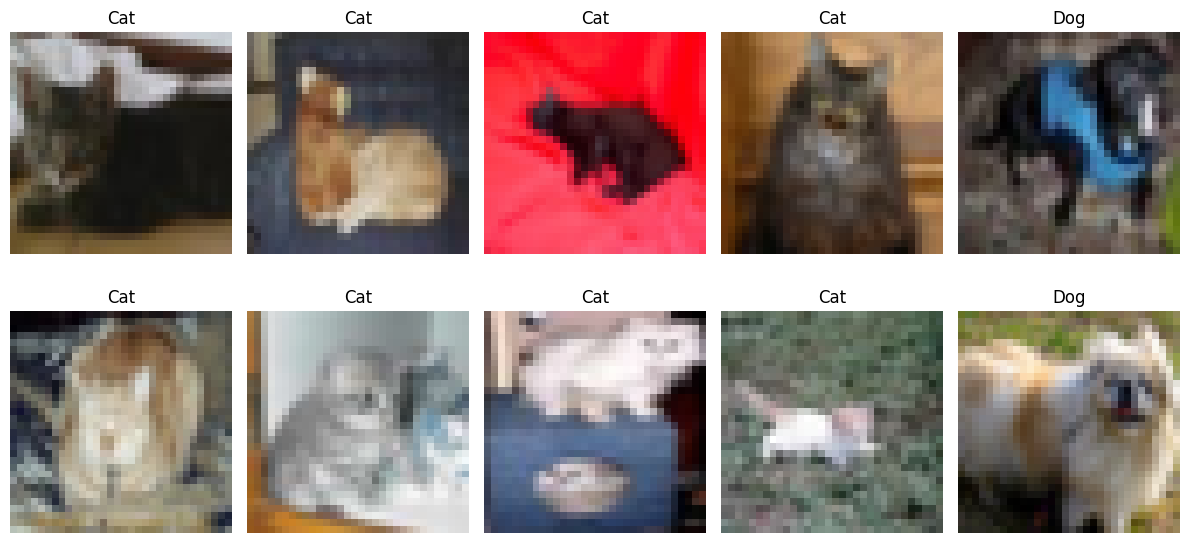

In [3]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

print(f"Full dataset shape - Training: {x_train_full.shape}, Test: {x_test_full.shape}")
print(f"Full dataset labels - Training: {y_train_full.shape}, Test: {y_test_full.shape}")

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nCIFAR-10 classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

# Filter to cats (3) and dogs (5)
cat_class = 3
dog_class = 5

# Training set
train_cat_mask = (y_train_full.flatten() == cat_class)
train_dog_mask = (y_train_full.flatten() == dog_class)
train_mask = train_cat_mask | train_dog_mask

x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask]
y_train = np.where(y_train == cat_class, 0, 1)

# Test set
test_cat_mask = (y_test_full.flatten() == cat_class)
test_dog_mask = (y_test_full.flatten() == dog_class)
test_mask = test_cat_mask | test_dog_mask

x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask]
y_test = np.where(y_test == dog_class, 1, 0)

print(f"\nFiltered dataset:")
print(f"  Training: {x_train.shape[0]} images")
print(f"  Test: {x_test.shape[0]} images")
print(f"  Image shape: {x_train.shape[1:]}")

print(f"\nTraining set - Cats: {(y_train == 0).sum()}, Dogs: {(y_train == 1).sum()}")
print(f"Test set - Cats: {(y_test == 0).sum()}, Dogs: {(y_test == 1).sum()}")

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten images for simple neural network (32x32x3 = 3072)
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f"\nFlattened shape: {x_train_flat.shape}")

# Visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(x_train[i])
    label = 'Cat' if y_train[i] == 0 else 'Dog'
    axes[row, col].set_title(f'{label}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
print("\nSaved sample images to 'sample_images.png'")
plt.show()

In [4]:
# Build the neural network
print("\n" + "="*50)
print("BUILDING NEURAL NETWORK")
print("="*50)

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(3072,), name='hidden_layer_1'),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")


BUILDING NEURAL NETWORK

Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 401,665


In [5]:
# Train the model
print("\n" + "="*50)
print("TRAINING THE MODEL")
print("="*50)

EPOCHS = 20
BATCH_SIZE = 32

print(f"Training for {EPOCHS} epochs with batch size {BATCH_SIZE}...")

history = model.fit(
    x_train_flat, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test_flat, y_test),
    verbose=1
)

print("\n✓ Training complete!")


TRAINING THE MODEL
Training for 20 epochs with batch size 32...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5532 - loss: 0.7021 - val_accuracy: 0.5860 - val_loss: 0.6739
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5752 - loss: 0.6743 - val_accuracy: 0.5955 - val_loss: 0.6660
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5827 - loss: 0.6691 - val_accuracy: 0.5920 - val_loss: 0.6663
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5905 - loss: 0.6656 - val_accuracy: 0.5965 - val_loss: 0.6636
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5855 - loss: 0.6668 - val_accuracy: 0.5715 - val_loss: 0.6750
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5942 - loss: 0.6622 - val_accuracy: 0.5560 - val_loss: 0.6805
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5985 - loss: 0.6602 - val_accuracy: 0.5810 - val_loss: 0.6717
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━


EVALUATING THE MODEL
Test Loss: 0.6600
Test Accuracy: 0.6025 (60.25%)
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Manual accuracy check: 1205/2000 (60.25%)

Saved training history to 'training_history.png'


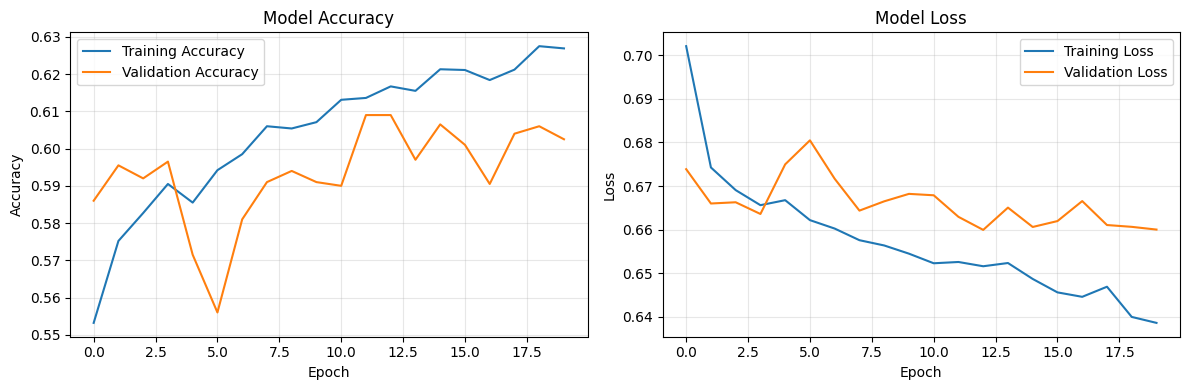


SAMPLE PREDICTIONS
Saved sample predictions to 'sample_predictions.png'


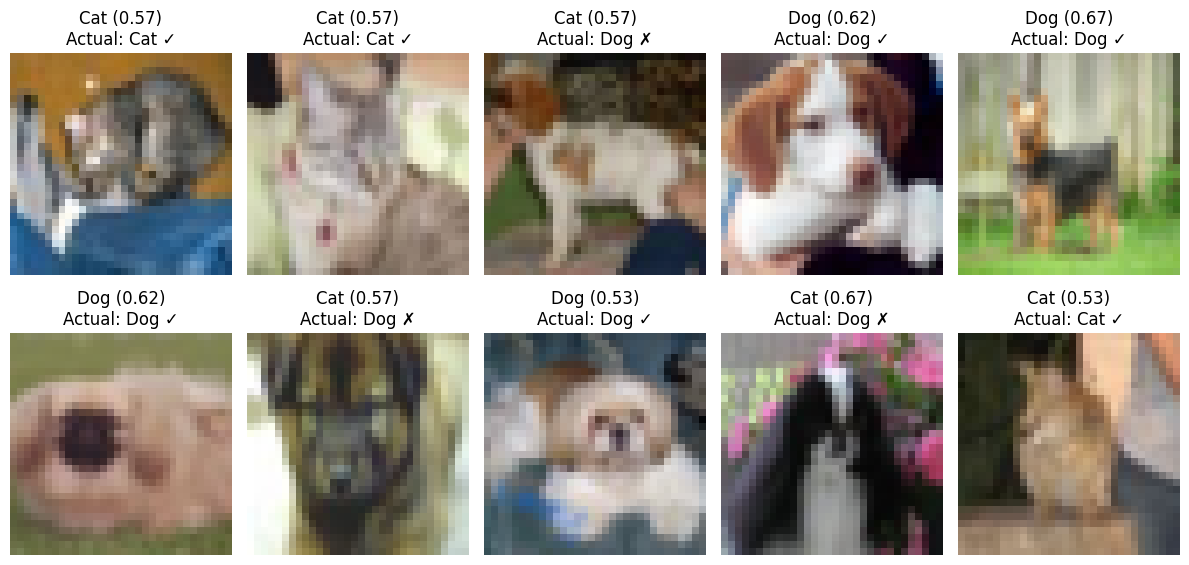

In [6]:
# Evaluate the model
print("\n" + "="*50)
print("EVALUATING THE MODEL")
print("="*50)

test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

predictions = model.predict(x_test_flat)
predicted_classes = (predictions > 0.5).astype(int).flatten()

correct = (predicted_classes == y_test.flatten()).sum()
total = len(y_test)
print(f"\nManual accuracy check: {correct}/{total} ({correct/total*100:.2f}%)")

# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
print("\nSaved training history to 'training_history.png'")
plt.show()

# Sample predictions
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row = i // 5
    col = i % 5

    img = x_test[i].reshape(1, -1)
    pred = model.predict(img, verbose=0)[0][0]
    pred_class = 'Dog' if pred > 0.5 else 'Cat'
    confidence = pred if pred > 0.5 else 1 - pred

    actual = 'Dog' if y_test[i] == 1 else 'Cat'
    correct = '✓' if (pred > 0.5) == (y_test[i] == 1) else '✗'

    axes[row, col].imshow(x_test[i])
    axes[row, col].set_title(f'{pred_class} ({confidence:.2f})\nActual: {actual} {correct}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print("Saved sample predictions to 'sample_predictions.png'")
plt.show()

In [9]:
# Export model weights
print("\n" + "="*50)
print("EXPORTING MODEL WEIGHTS")
print("="*50)

import os
os.makedirs('saved_models', exist_ok=True)

# Method 1: Save entire model
model_path = 'saved_models/dog_cat_classifier_full.h5'
model.save(model_path)
print(f"✓ Saved full model to: {model_path}")
print(f"  File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

# Method 2: Save only weights
weights_path = 'saved_models/dog_cat_classifier_weights.h5'
model.save_weights(weights_path)
print(f"✓ Saved weights only to: {weights_path}")
print(f"  File size: {os.path.getsize(weights_path) / 1024 / 1024:.2f} MB")

# Method 3: SavedModel format
savedmodel_path = 'saved_models/dog_cat_classifier_savedmodel'
model.save(savedmodel_path)
print(f"✓ Saved in SavedModel format to: {savedmodel_path}/")

# Verify
print("\nVerifying saved model...")
loaded_model = keras.models.load_model(model_path)
test_loss_loaded, test_acc_loaded = loaded_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Loaded model test accuracy: {test_acc_loaded:.4f}")
print(f"Original model test accuracy: {test_accuracy:.4f}")
print(f"Match: {'✓' if abs(test_acc_loaded - test_accuracy) < 0.001 else '✗'}")

print("\n✓ Model weights exported successfully!")


EXPORTING MODEL WEIGHTS
✓ Saved full model to: saved_models/dog_cat_classifier_full.h5
  File size: 4.63 MB


ValueError: The filename must end in `.weights.h5`. Received: filepath=saved_models/dog_cat_classifier_weights.h5

In [8]:
# Experiment 1: Bigger model
print("EXPERIMENT 1: Bigger model")
print("="*50)

model_exp1 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(3072,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_exp1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_exp1 = model_exp1.fit(
    x_train_flat, y_train,
    batch_size=64,
    epochs=30,
    validation_data=(x_test_flat, y_test),
    verbose=1
)

_, acc_exp1 = model_exp1.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nExperiment 1 Accuracy: {acc_exp1*100:.2f}%")
print(f"Original Accuracy:     {test_accuracy*100:.2f}%")
print(f"Improvement: {(acc_exp1 - test_accuracy)*100:.2f}%")

EXPERIMENT 1: Bigger model
Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5567 - loss: 0.6969 - val_accuracy: 0.5920 - val_loss: 0.6679
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5655 - loss: 0.6784 - val_accuracy: 0.5970 - val_loss: 0.6647
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5776 - loss: 0.6703 - val_accuracy: 0.5795 - val_loss: 0.6740
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5854 - loss: 0.6649 - val_accuracy: 0.5640 - val_loss: 0.6739
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5955 - loss: 0.6575 - val_accuracy: 0.5620 - val_loss: 0.6775
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5994 - loss: 0.6569 - val_accuracy: 0.5525 - val_loss: 0.6867
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6062 - loss: 0.6532 - val_accuracy: 0.5550 - val_loss: 0.6909
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.607